In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [2]:
BTC_Ticker = "BTC-USD"
ETH_Ticker = "ETH-USD"

In [3]:
start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 1, 1)

In [4]:
BTC_1d = yf.Ticker(BTC_Ticker).history(interval="1d", start=start_date, end=end_date)
ETH_1d = yf.Ticker(ETH_Ticker).history(interval="1d", start=start_date, end=end_date)

In [5]:
BTC_5d = yf.Ticker(BTC_Ticker).history(interval="5d", start=start_date, end=end_date)
ETH_5d = yf.Ticker(ETH_Ticker).history(interval="5d", start=start_date, end=end_date)

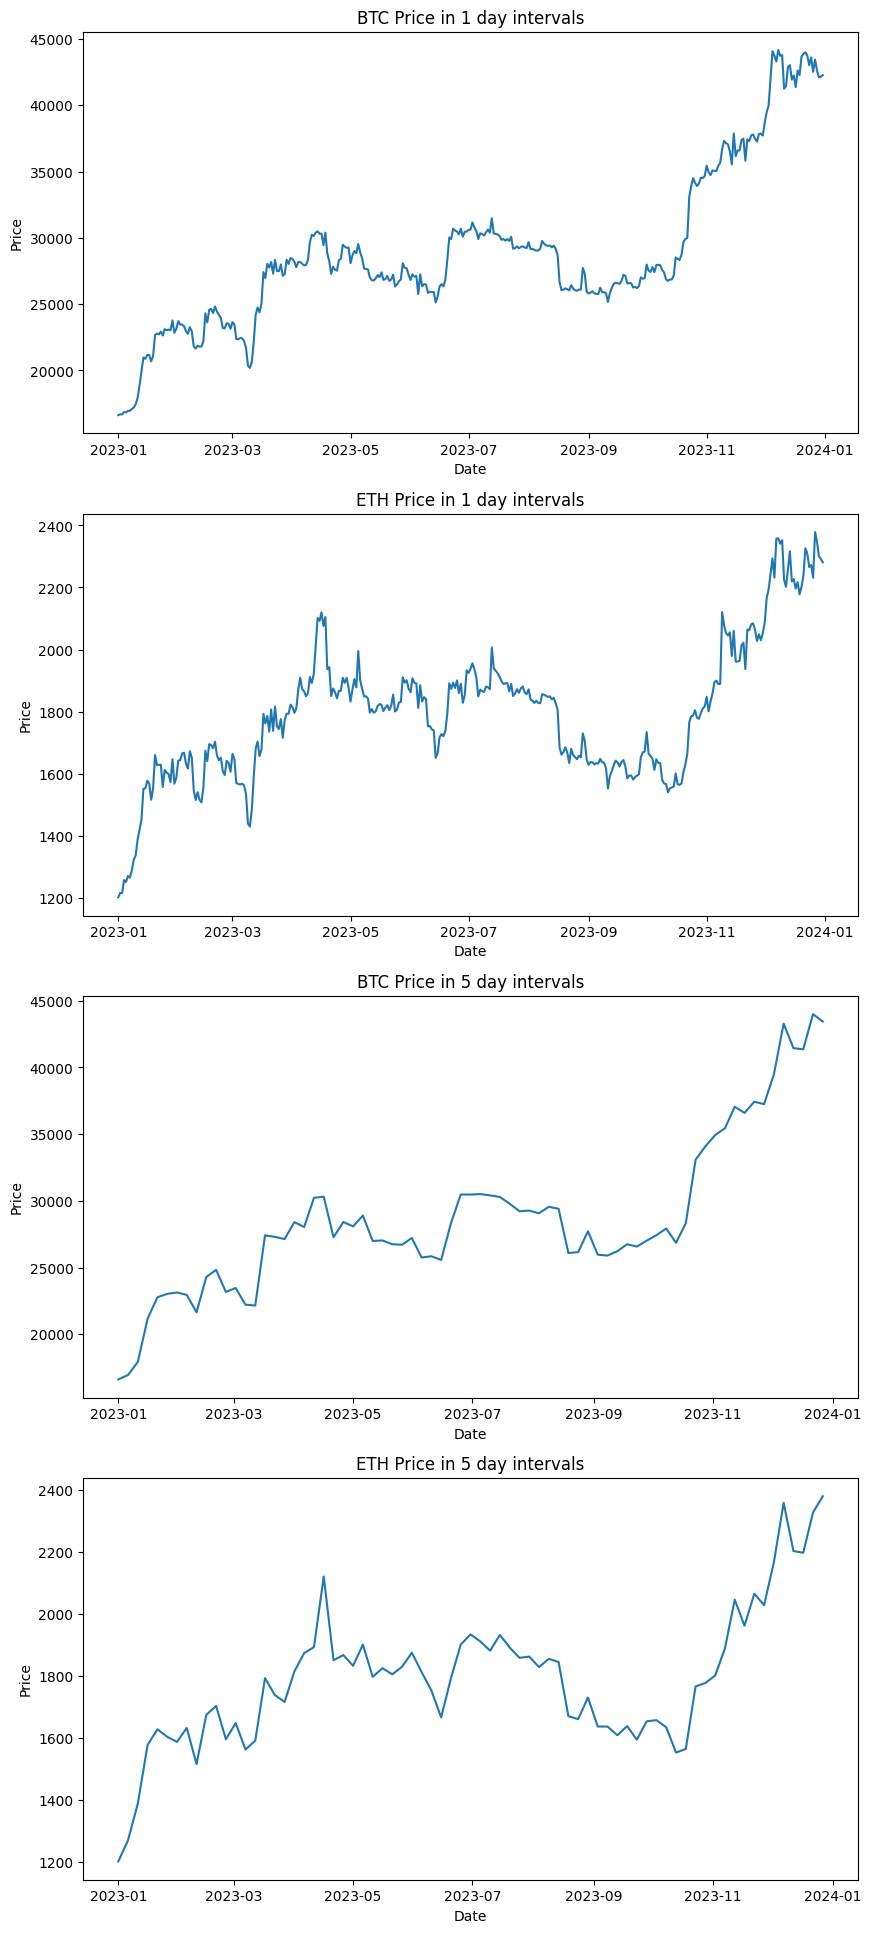

In [6]:
plt.figure(figsize=(10,24))

plt.subplot(4,1,1)
plt.plot(BTC_1d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("BTC Price in 1 day intervals")

plt.subplot(4,1,2)
plt.plot(ETH_1d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("ETH Price in 1 day intervals")

plt.subplot(4,1,3)
plt.plot(BTC_5d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("BTC Price in 5 day intervals")

plt.subplot(4,1,4)
plt.plot(ETH_5d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("ETH Price in 5 day intervals")

plt.show()

In [7]:
from statistics import mean, stdev

In [8]:
period = 20
correlation = 2

In [9]:
def BollingerBand(stock):
    def SMA(series):
        return series.rolling(period).apply(mean)

    def STD(series):
        return series.rolling(period).apply(stdev)

    def UpperBound(series):
        std = STD(series)
        sma = SMA(series)
        return sma + std * correlation

    def LowerBound(series):
        std = STD(series)
        sma = SMA(series)
        return sma - std * correlation

    middle_bound = pd.Series(SMA(stock), name="middle_bound")
    upper_bound = pd.Series(UpperBound(stock), name="upper_bound")
    lower_bound = pd.Series(LowerBound(stock), name="lower_bound")
    bollinger_band = pd.concat([middle_bound, upper_bound, lower_bound], axis="columns")

    return bollinger_band

<Axes: xlabel='Date'>

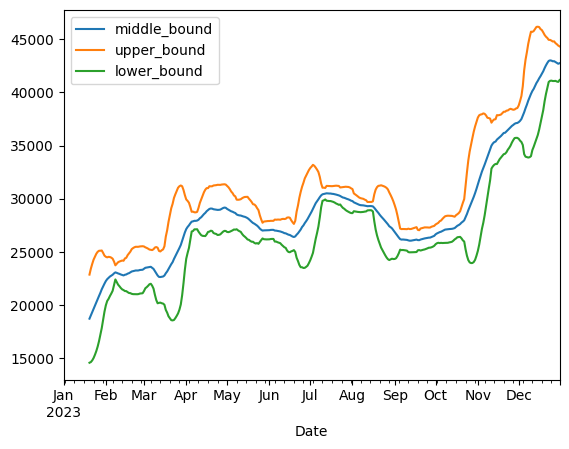

In [10]:
# This is just for test.
BollingerBand(BTC_1d.Close).plot()

In [11]:
def KeltnerChannel(stock):
    def SMA(series):
        return series.rolling(period).apply(mean)

    def return_max(series):
        return max(
            series["high_low_diff"],
            series["high_prevclose_diff"],
            series["low_prev_close_diff"],
        )

    def TR(series):
        high_low_diff = series.High - series.Low
        high_prevclose_diff = series.High - series.Close.shift(periods=1)
        low_prev_close_diff = series.Low - series.Close.shift(periods=1)
        TR = pd.concat(
            [high_low_diff, high_prevclose_diff, low_prev_close_diff],
            axis=1,
        )
        TR.columns = ["high_low_diff", "high_prevclose_diff", "low_prev_close_diff"]
        TR["TR"] = TR.apply(return_max, axis=1)
        return TR["TR"]

    def ATR(series):
        tr = TR(series)
        prev_atr = mean(tr[:14])
        atr = pd.Series(np.nan, index=series.index)
        for day in series.index[14:]:
            current_atr = (tr.loc[day] + 13 * prev_atr) / 14
            atr.loc[day] = current_atr
            prev_atr = current_atr

        return atr

    def UpperBound(sma, atr):
        return sma + atr * correlation

    def LowerBound(sma, atr):
        return sma - atr * correlation

    atr = ATR(stock)
    sma = SMA(stock.Close)
    upper_bound = pd.Series(UpperBound(sma, atr), name="upper_bound")
    lower_bound = pd.Series(LowerBound(sma, atr), name="lower_bound")
    keltner_channel = pd.concat([upper_bound, lower_bound], axis="columns")
    return keltner_channel

<Axes: xlabel='Date'>

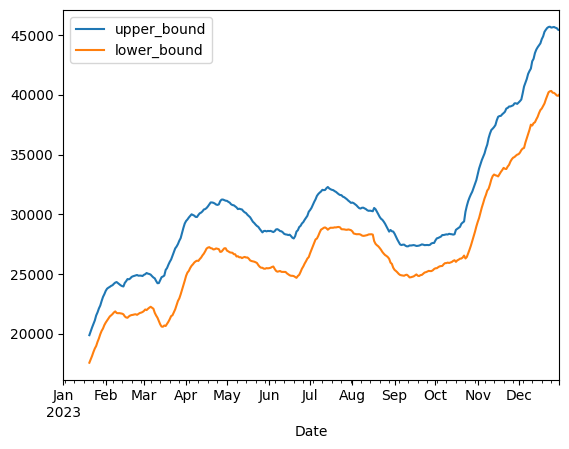

In [12]:
# This is just for plotting.
KeltnerChannel(BTC_1d).plot()

In [13]:
def RSI(series, n=14):
    dUp, dDown = series.copy().diff(), series.copy().diff()
    dUp[dUp < 0] = 0
    dDown[dDown > 0] = 0
    RolUp = dUp.rolling(n).apply(mean)
    RolDown = dDown.rolling(n).apply(mean).apply(abs)
    RS = RolUp / RolDown
    return 100 - (100 / (1 + RS))

<Axes: xlabel='Date'>

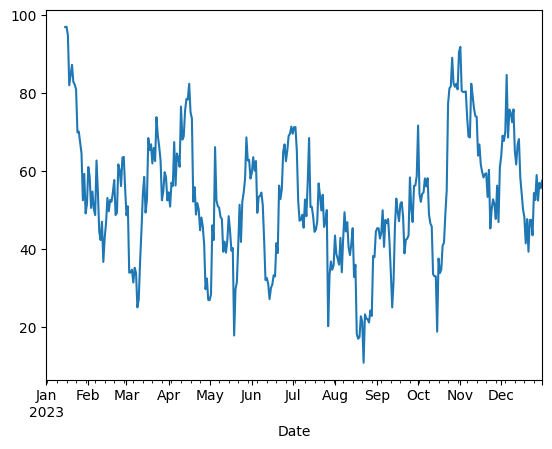

In [14]:
# This is just for test.
RSI(ETH_1d.Close).plot()

In [15]:
def backtest(stock, init_fund=1000, fund_rate = 1):
    bollingerband_analysis = BollingerBand(stock.Close)
    keltnerchannel_analysis = KeltnerChannel(stock)
    rsi_analysis = RSI(stock.Close)

    oversold = 30
    overbought = 70

    current_share = 0
    current_fund = init_fund
    buy_holding = False
    sell_holding = False

    fund_per_day = pd.Series(0, index=stock.index)
    for day in stock.index:
        stock_price = stock.loc[day].Close
        b_price = bollingerband_analysis.loc[day]
        k_price = keltnerchannel_analysis.loc[day]
        rsi_rate = rsi_analysis.loc[day]
        # Buy
        if (
            not buy_holding
            and stock_price <= b_price["lower_bound"]
            and stock_price <= k_price["lower_bound"]
            and rsi_rate <= overbought
        ):
            if sell_holding:
                current_fund += (stock_price) * current_share
                current_share = 0
                sell_holding = False
            current_share += fund_rate * current_fund / stock_price
            current_fund -= current_share * stock_price
            buy_holding = True

        # Sell
        elif (
            not sell_holding
            and stock_price >= b_price.loc["upper_bound"]
            and stock_price >= k_price["upper_bound"]
            and rsi_rate >= oversold
        ):
            if buy_holding:
                current_fund += stock_price * current_share
                current_share = 0
                buy_holding = False
            current_share += fund_rate * current_fund / stock_price
            current_fund -= current_share * stock_price
            sell_holding = True

        fund_per_day.loc[day] = current_fund + current_share * stock_price

    return fund_per_day

In [16]:
fund_rate = 0.4

In [17]:
BTC_1D_Result = backtest(BTC_1d, fund_rate=fund_rate)
BTC_5D_Result = backtest(BTC_5d, fund_rate=fund_rate)
ETH_1D_Result = backtest(ETH_1d, fund_rate=fund_rate)
ETH_5D_Result = backtest(ETH_5d, fund_rate=fund_rate)

C:\Users\Win\AppData\Local\Temp\ipykernel_11400\2410666839.py:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1004.058741736658' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  fund_per_day.loc[day] = current_fund + current_share * stock_price
C:\Users\Win\AppData\Local\Temp\ipykernel_11400\2410666839.py:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1012.1299974167882' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  fund_per_day.loc[day] = current_fund + current_share * stock_price
C:\Users\Win\AppData\Local\Temp\ipykernel_11400\2410666839.py:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '997.3579079189537' has dtype incompatible with int64, please exp

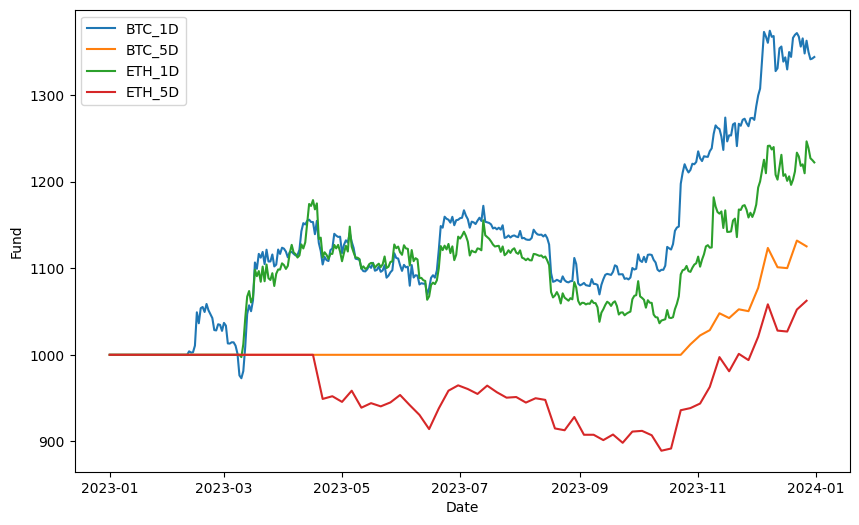

In [18]:
# Plotting Strategy Backtest
plt.figure(figsize=(10, 6))
plt.plot(BTC_1D_Result, label="BTC_1D")
plt.plot(BTC_5D_Result, label="BTC_5D")
plt.plot(ETH_1D_Result, label="ETH_1D")
plt.plot(ETH_5D_Result, label="ETH_5D")
plt.xlabel("Date")
plt.ylabel("Fund")
plt.legend()
plt.show()

In [19]:
def NetProfit(series, init_fund=1000):
    return series.iloc[-1] - init_fund


def SharpeRatio(series, risk_free_ratio=24, init_fund=1000):
    net_profit = NetProfit(series, init_fund)
    portfolio_ratio = (net_profit - init_fund) / init_fund
    std = stdev(series)
    return (portfolio_ratio - risk_free_ratio) / std


def MaxDrawDown(series):
    biggest_max = 0
    lowest_min = 0
    for day1 in range(len(series.index) - 1):
        for day2 in range(day1 + 1, len(series.index)):
            if series.iloc[day1] - series.iloc[day2] > biggest_max - lowest_min:
                biggest_max = series.iloc[day1]
                lowest_min = series.iloc[day2]
    return (lowest_min - biggest_max) / biggest_max * 100

In [20]:
result = f"""BTC 1 day interval results are listed below
      \tNet Profit : {NetProfit(BTC_1D_Result):.2f}$
      \tSharpe Ratio : {SharpeRatio(BTC_1D_Result):.2f}%
      \tMax Drawdown : {MaxDrawDown(BTC_1D_Result):.2f}%
BTC 5 day interval results are listed below
\tNet Profit : {NetProfit(BTC_5D_Result):.2f}$
\tSharpe Ratio : {SharpeRatio(BTC_5D_Result):.2f}%
\tMax Drawdown : {MaxDrawDown(BTC_5D_Result):.2f}%
ETH 1 day interval results are listed below
\tNet Profit : {NetProfit(ETH_1D_Result):.2f}$
\tSharpe Ratio : {SharpeRatio(ETH_1D_Result):.2f}%
\tMax Drawdown : {MaxDrawDown(ETH_1D_Result):.2f}%
ETH 5 day interval results are listed below
\tNet Profit : {NetProfit(ETH_5D_Result):.2f}$
\tSharpe Ratio : {SharpeRatio(ETH_5D_Result):.2f}%
\tMax Drawdown : {MaxDrawDown(ETH_5D_Result):.2f}%
"""
print(result)

BTC 1 day interval results are listed below
      	Net Profit : 343.88$
      	Sharpe Ratio : -0.26%
      	Max Drawdown : -8.73%
BTC 5 day interval results are listed below
	Net Profit : 125.21$
	Sharpe Ratio : -0.78%
	Max Drawdown : -2.07%
ETH 1 day interval results are listed below
	Net Profit : 222.14$
	Sharpe Ratio : -0.40%
	Max Drawdown : -12.07%
ETH 5 day interval results are listed below
	Net Profit : 62.43$
	Sharpe Ratio : -0.60%
	Max Drawdown : -11.07%

